# Notebook 1: Exploratory Data Analysis (EDA) & Preprocessing

#### Dataset
- IBM Telco Customer Churn dataset available on GitHub: https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv

## 1. Imports and Configuration

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Reproducibility
RANDOM_STATE = 42

# Consistent plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

PALETTE = {'No': '#43A047', 'Yes': '#F44336'}
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Initial Inspection

In [43]:
# Load raw dataset
df_raw = pd.read_csv('data/Dataset-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

Dataset shape: (7043, 21)
Rows: 7,043  |  Columns: 21


In [44]:
df_raw.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [45]:
# Data types and non-null counts 
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [46]:
# Descriptive statistics for numeric columns
df_raw.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [47]:
# Statistical Summary for categorical columns
df_raw.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


## 3. Data Cleaning
### 3.1 Handling the `TotalCharges` Column

In [48]:
# TotalCharges should be numeric but was read as object (blank strings exist)
print("Unique problematic values in TotalCharges:")
print(df_raw[df_raw['TotalCharges'].str.strip() == ''][['customerID','tenure','TotalCharges']])

Unique problematic values in TotalCharges:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [49]:
df = df_raw.copy()

# Convert TotalCharges to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df['TotalCharges'].isna().sum()
print(f"Rows with missing TotalCharges: {missing}")
print("These are ALL new customers with tenure = 0:")
print(df[df['TotalCharges'].isna()][['tenure','MonthlyCharges','TotalCharges']].head())

# Drop these 11 rows (less than 0.2% of data — negligible impact)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nDataset shape after dropping missing TotalCharges: {df.shape}")

Rows with missing TotalCharges: 11
These are ALL new customers with tenure = 0:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN

Dataset shape after dropping missing TotalCharges: (7032, 21)


### 3.2 Drop `customerID` (non-predictive identifier)

In [50]:
df.drop(columns=['customerID'], inplace=True)
print("customerID removed. Remaining columns:", df.columns.tolist())

customerID removed. Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 3.3 Normalise Service-Related Categories

Several service columns (e.g. `OnlineSecurity`, `StreamingTV`) contain the value
**"No internet service"** for customers who don't have internet — which is functionally
equivalent to **"No"**. Similarly, `MultipleLines` has **"No phone service"**.
We consolidate these to a simple binary "No" so all service flags are consistently Yes/No.

In [51]:
# Columns where "No internet service" maps to "No"
internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']

for col in internet_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

# Verify — each service column should now be exactly Yes/No
print("Unique values per service column after normalisation:")
for col in internet_cols + ['MultipleLines']:
    print(f"  {col}: {sorted(df[col].unique())}")

Unique values per service column after normalisation:
  OnlineSecurity: ['No', 'Yes']
  OnlineBackup: ['No', 'Yes']
  DeviceProtection: ['No', 'Yes']
  TechSupport: ['No', 'Yes']
  StreamingTV: ['No', 'Yes']
  StreamingMovies: ['No', 'Yes']
  MultipleLines: ['No', 'Yes']


### 3.4 Final Missing-Value Check

In [52]:
missing_summary = df.isnull().sum()
print("Missing values per column:\n", missing_summary[missing_summary > 0])
print("\n✅ No remaining missing values." if missing_summary.sum() == 0 else "⚠️  Missing values still present.")

Missing values per column:
 Series([], dtype: int64)

✅ No remaining missing values.


## 4. Exploratory Data Analysis (EDA)
### 4.1 Target Variable — Churn Distribution

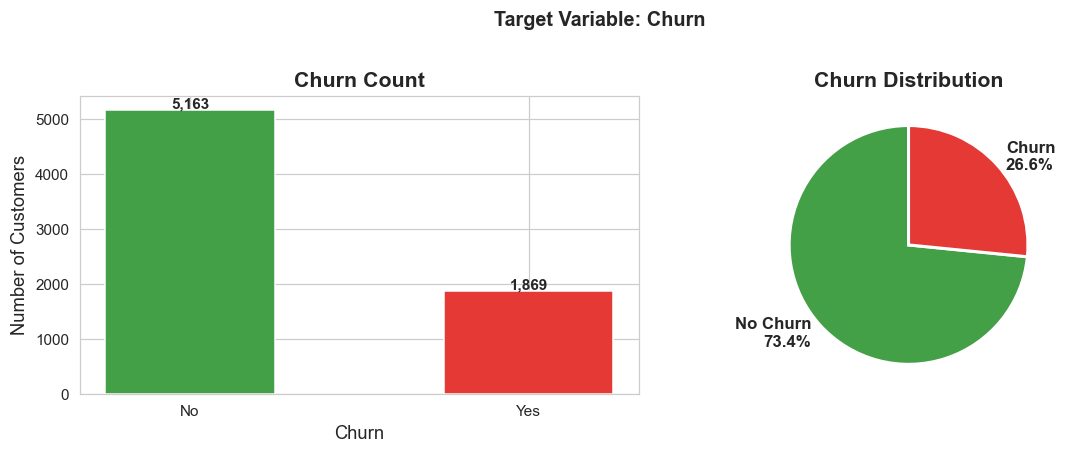

Churn rate: 26.6%  —  Class imbalance ratio: 2.8:1


In [53]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=['#43A047', '#E53935'], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Churn')

# Pie
axes[1].pie(churn_pct.values,
            labels=[f'No Churn\n{churn_pct["No"]:.1f}%',
                    f'Churn\n{churn_pct["Yes"]:.1f}%'],
            colors=['#43A047', '#E53935'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            autopct='', textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Churn Distribution', fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.1f}%  —  Class imbalance ratio: "
      f"{churn_counts['No']/churn_counts['Yes']:.1f}:1")

### 4.2 Numerical Features — Distribution and Outlier Analysis

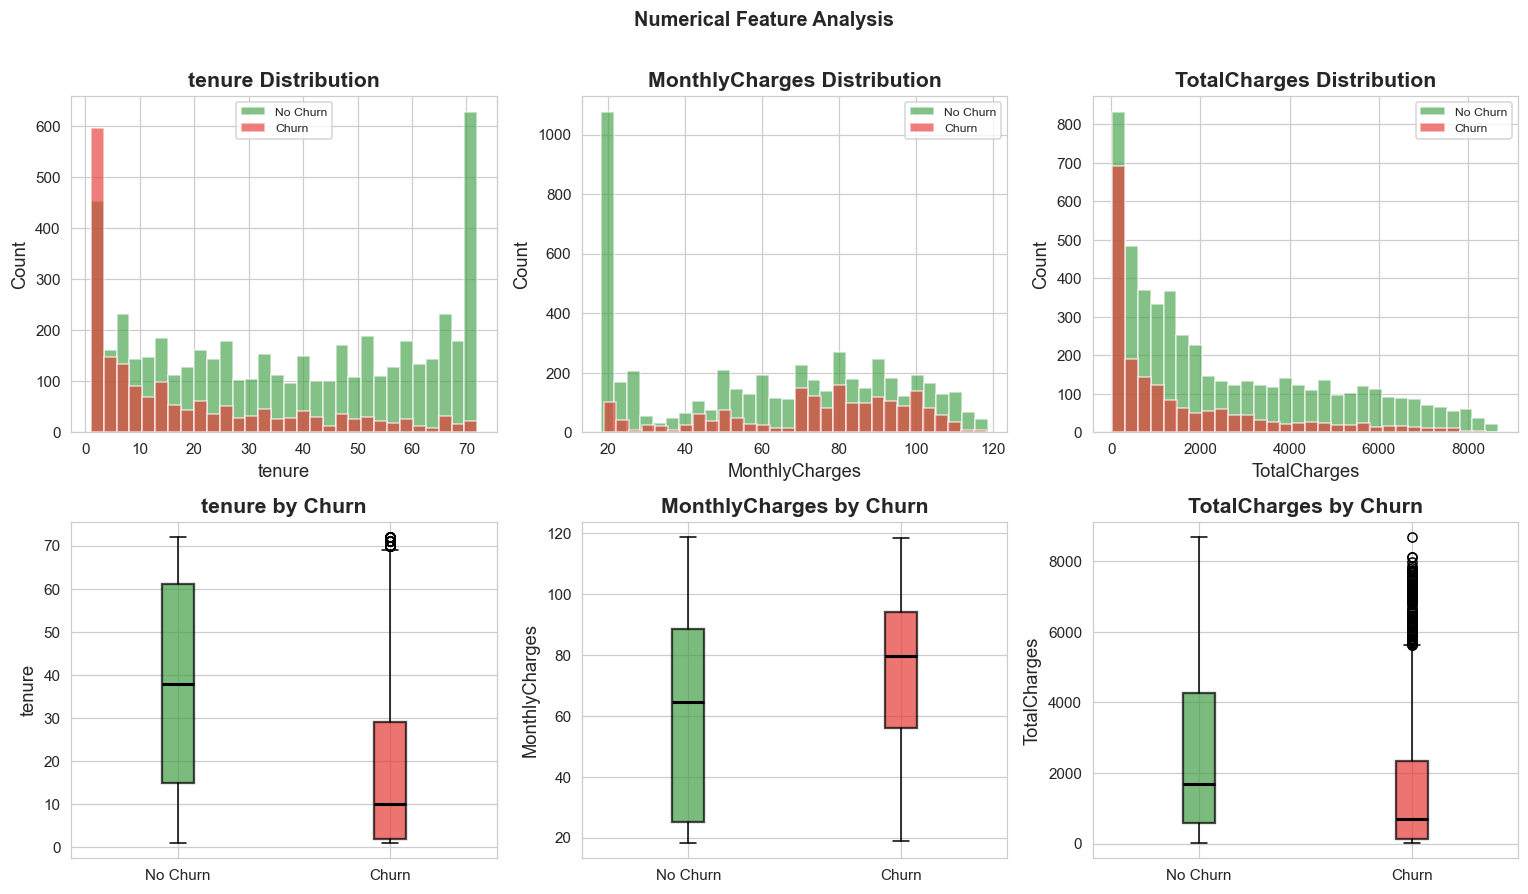


Mean values by Churn status:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.65,61.31,2555.34
Yes,17.98,74.44,1531.80


In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Histogram by churn
    ax = axes[0, i]
    for churn_val, color, label in [
        ('No', '#43A047', 'No Churn'),
        ('Yes', '#E53935', 'Churn')
    ]:
        ax.hist(df[df['Churn'] == churn_val][col].dropna(),
                bins=30, alpha=0.65, color=color,
                label=label, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Box plot by churn
    ax2 = axes[1, i]
    data_no  = df[df['Churn'] == 'No'][col].dropna()
    data_yes = df[df['Churn'] == 'Yes'][col].dropna()
    bp = ax2.boxplot(
        [data_no, data_yes],
        labels=['No Churn', 'Churn'],
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], ['#43A047', '#E53935']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'{col} by Churn', fontweight='bold')
    ax2.set_ylabel(col)

plt.suptitle('Numerical Feature Analysis', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nMean values by Churn status:")
display(df.groupby('Churn')[num_cols].mean().round(2))

### 4.3 Categorical Features — Churn Rates

In [55]:
# All categorical columns except Churn itself
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
print("Categorical columns:", cat_cols)

Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


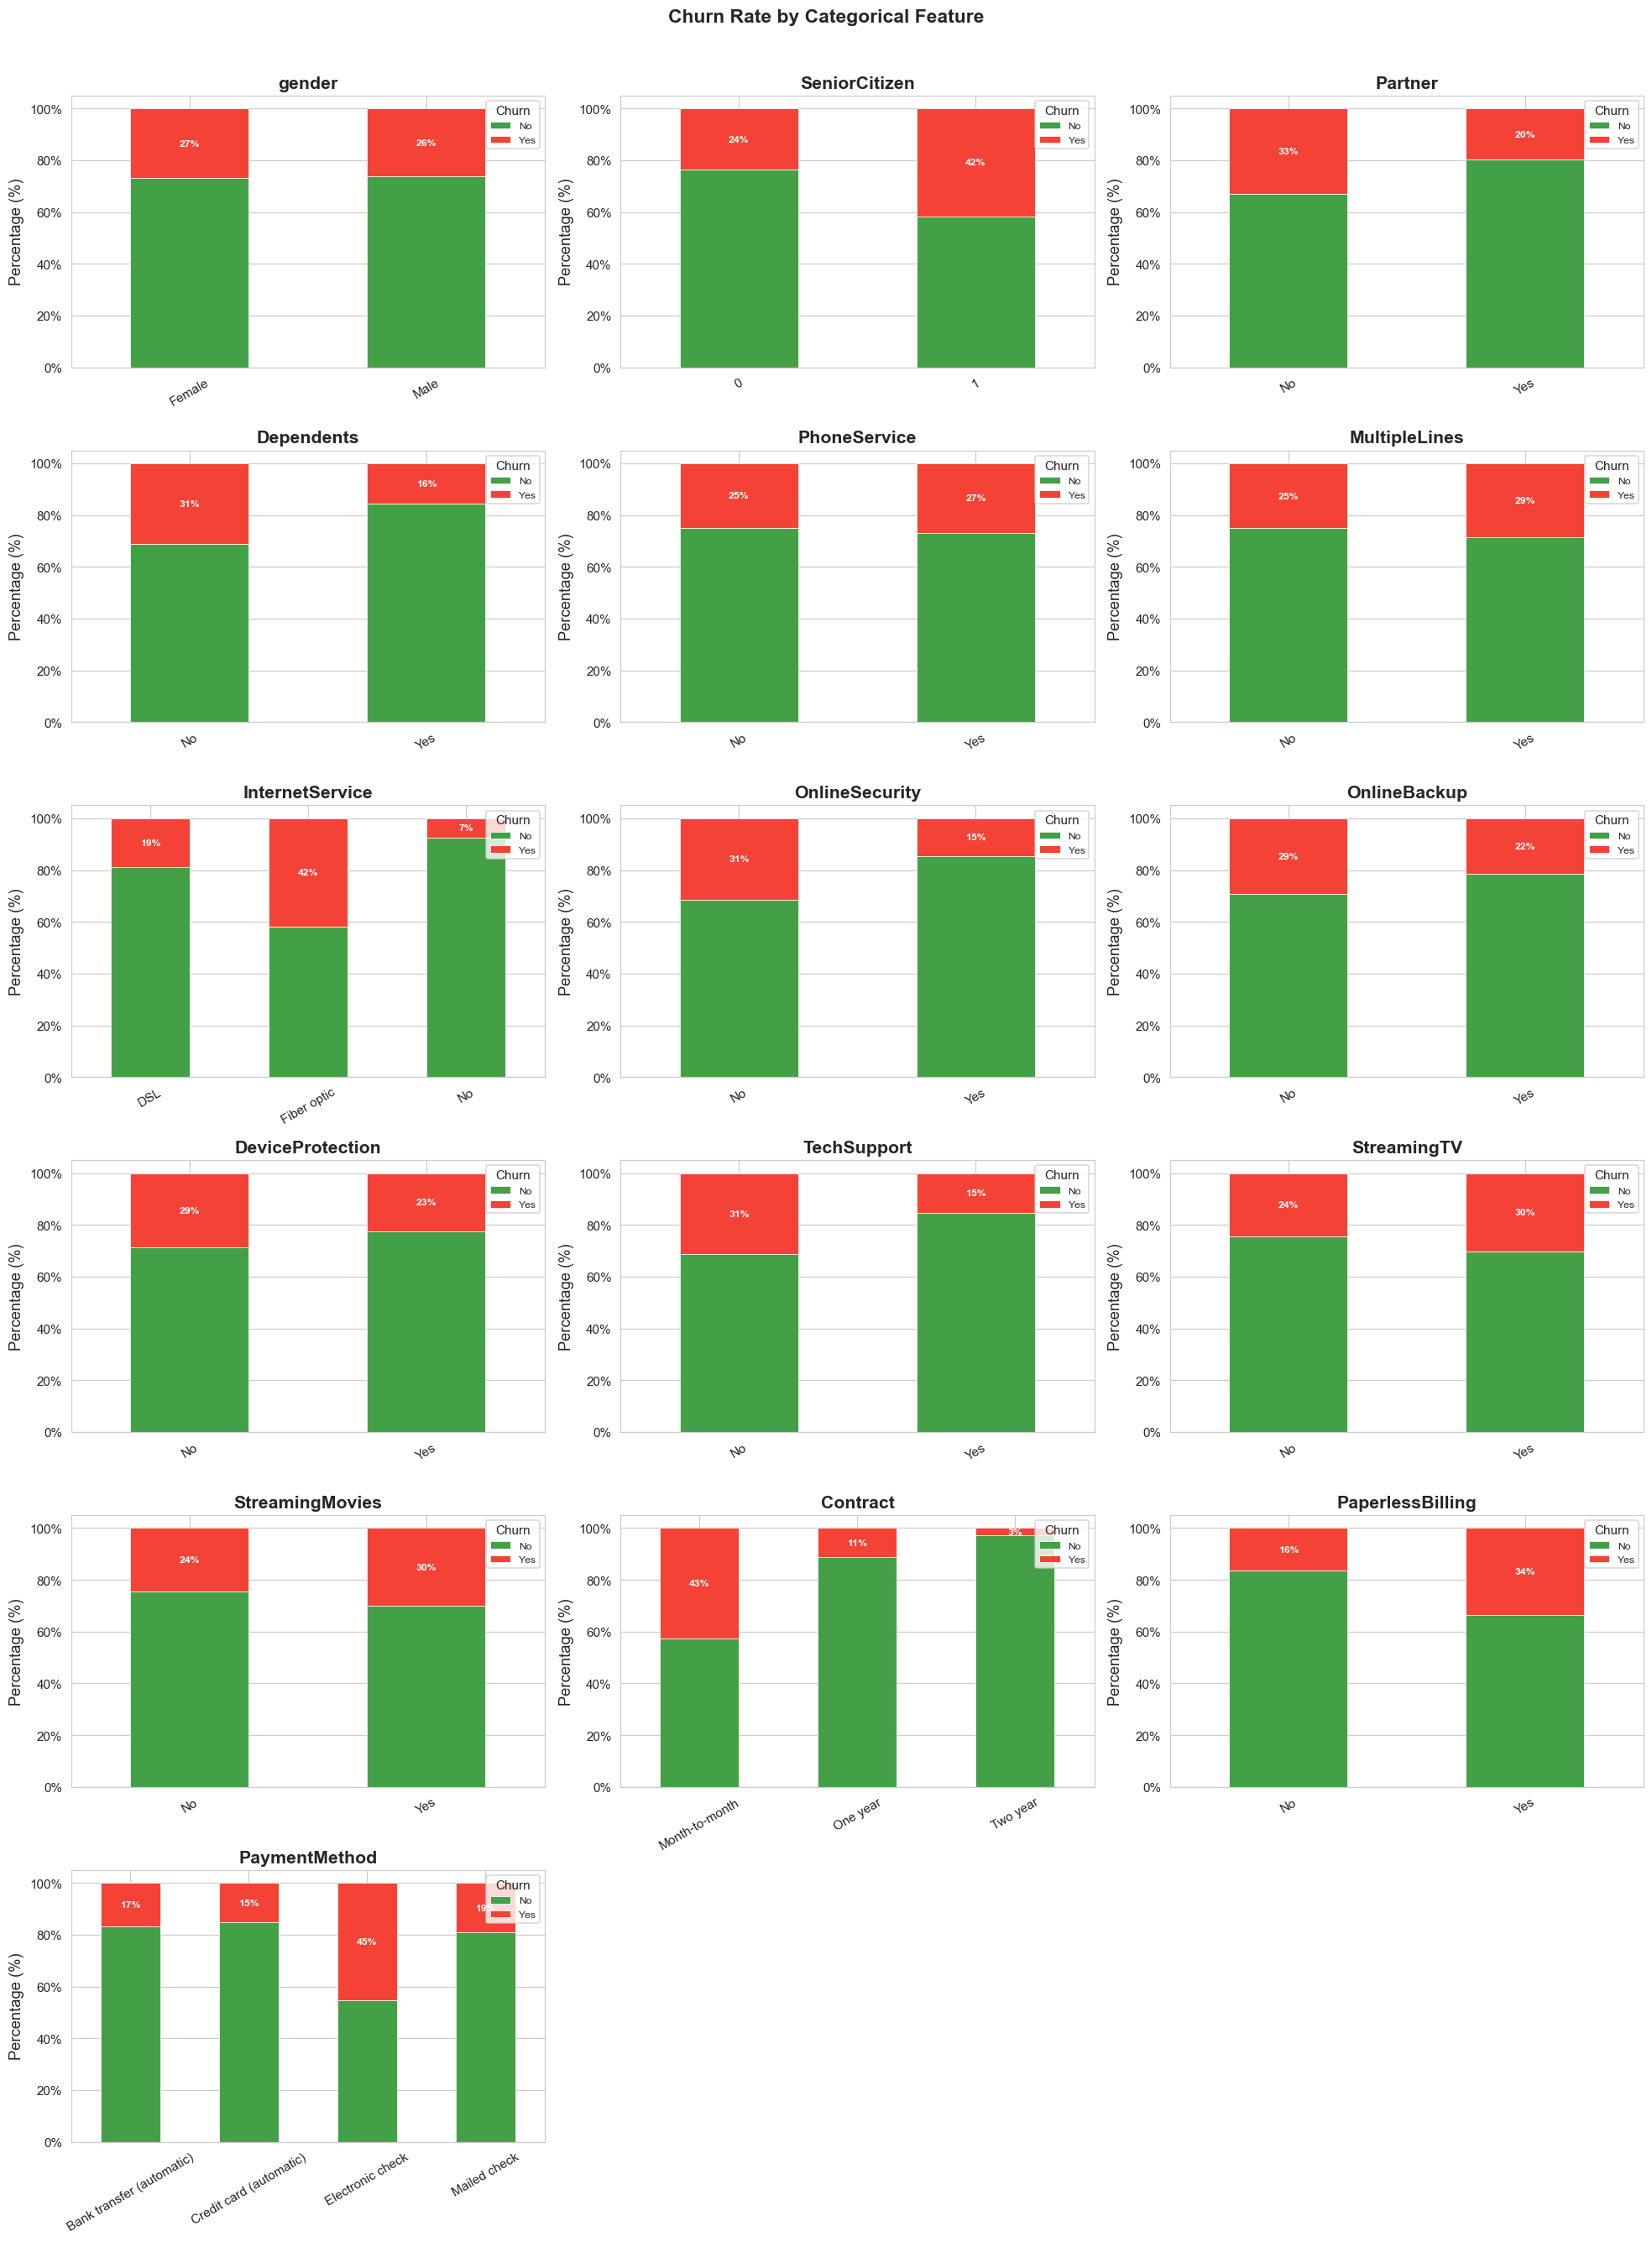

In [56]:
def churn_rate_barplot(df, col, ax):
    """Stacked bar chart showing churn rate (%) per category."""
    ct = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=[PALETTE['No'], PALETTE['Yes']],
                edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Churn', labels=['No', 'Yes'], loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    # Annotate churn % on bars
    for i, (_, row) in enumerate(ct_pct.iterrows()):
        ax.text(i, row['No'] + row['Yes'] / 2,
                f"{row.get('Yes', 0):.0f}%", ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)   # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate_barplot(df, col, axes[i])

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [57]:
# Churn rate summary table for categorical features
print(f"{'Feature':<22} {'Category':<30} {'Churn%':>8}  {'Count':>8}")
print('-' * 72)
for col in cat_cols:
    rates = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100).round(1)
    for cat, rate in rates.items():
        n = df[col].value_counts()[cat]
        print(f"{col:<22} {str(cat):<30} {rate:>7.1f}%  {n:>8,}")
    print()

Feature                Category                         Churn%     Count
------------------------------------------------------------------------
gender                 Female                            27.0%     3,483
gender                 Male                              26.2%     3,549

SeniorCitizen          0                                 23.7%     5,890
SeniorCitizen          1                                 41.7%     1,142

Partner                No                                33.0%     3,639
Partner                Yes                               19.7%     3,393

Dependents             No                                31.3%     4,933
Dependents             Yes                               15.5%     2,099

PhoneService           No                                25.0%       680
PhoneService           Yes                               26.7%     6,352

MultipleLines          No                                25.1%     4,065
MultipleLines          Yes                    

### 4.4 Correlation Analysis

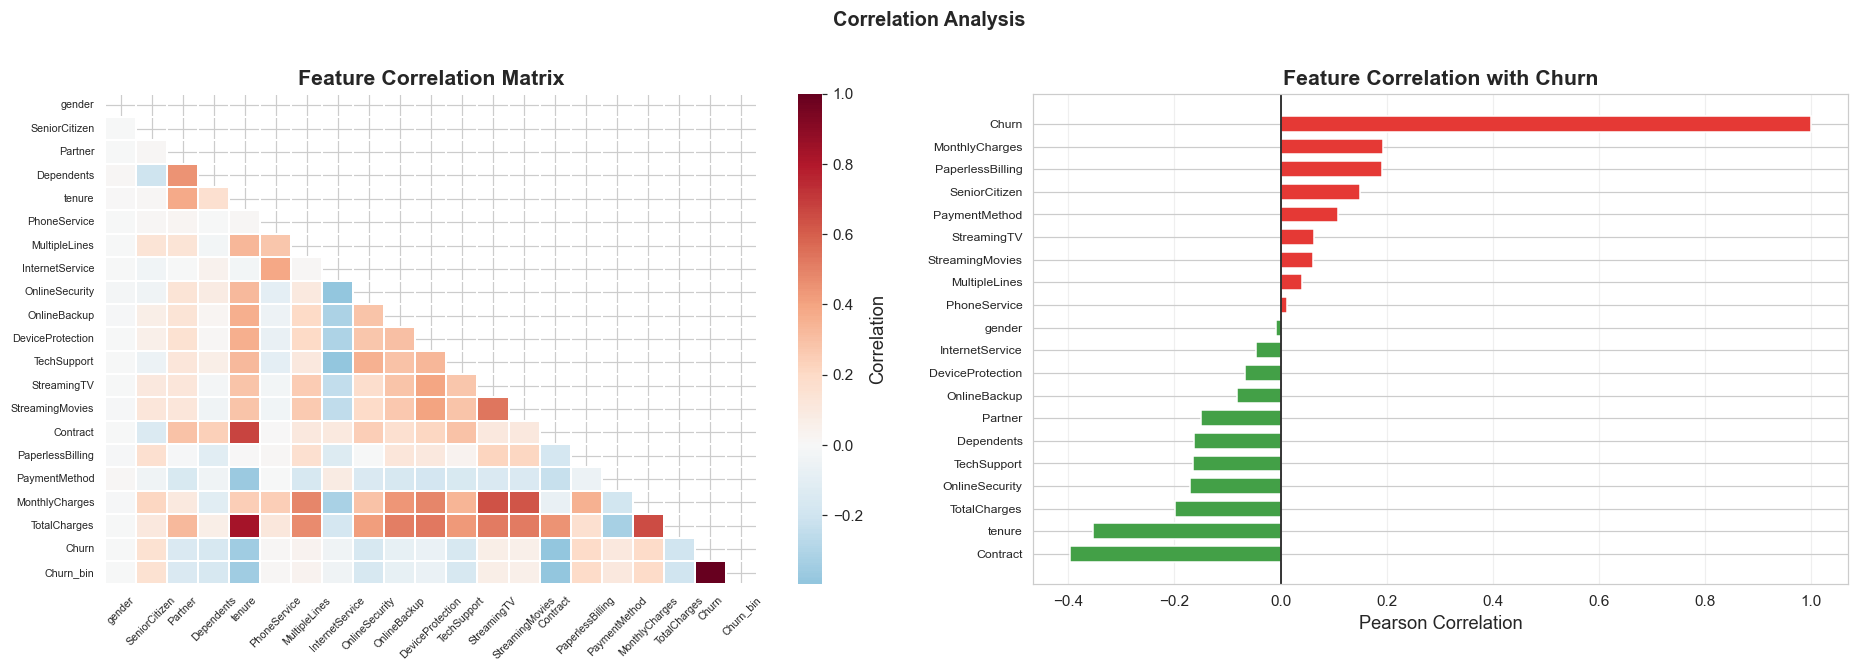


Top 5 features positively correlated with Churn:
PaymentMethod       0.108
SeniorCitizen       0.151
PaperlessBilling    0.191
MonthlyCharges      0.193
Churn               1.000

Top 5 features negatively correlated with Churn:
Contract         -0.396
tenure           -0.354
TotalCharges     -0.199
OnlineSecurity   -0.171
TechSupport      -0.165


In [58]:
# Encode for correlation
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))
df_corr.drop(columns=['customerID'], errors='ignore', inplace=True)

corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, ax=axes[0], linewidths=0.3,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Churn correlation bar chart
churn_corr = corr_matrix['Churn_bin'].drop('Churn_bin').sort_values()
colors_corr = ['#E53935' if v > 0 else '#43A047' for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values,
             color=colors_corr, edgecolor='white', height=0.7)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Feature Correlation with Churn',
                   fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Correlation Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 5 features positively correlated with Churn:")
print(churn_corr.tail(5).round(3).to_string())
print("\nTop 5 features negatively correlated with Churn:")
print(churn_corr.head(5).round(3).to_string())

## 5. Feature Engineering and Encoding
### 5.1 Binary Encoding

In [59]:
df_model = df.copy()

# Map binary Yes/No and gender to 1/0
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn']

for col in binary_cols:
    df_model[col] = df_model[col].map(binary_map)

print("Binary columns encoded. Sample values:")
print(df_model[binary_cols].head(3))

Binary columns encoded. Sample values:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0       0        1           0             0                 1              0   
1       1        0           0             1                 0              0   
2       1        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   

   StreamingMovies  Churn  
0                0      0  
1                0      0  
2                0      1  


### 5.2 One-Hot Encoding for Multi-Class Categorical Features

In [60]:
# One-hot encode the three nominal features (drop first to avoid dummy trap)
df_model = pd.get_dummies(df_model,
                           columns=['InternetService', 'Contract', 'PaymentMethod'],
                           drop_first=True)

print(f"Shape after one-hot encoding: {df_model.shape}")
print("\nAll columns:")
print(df_model.columns.tolist())

Shape after one-hot encoding: (7032, 24)

All columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 5.3 Feature Scaling (StandardScaler on Numeric Features)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_model[scale_cols] = scaler.fit_transform(df_model[scale_cols])

print("Numeric features scaled with StandardScaler.")
print(df_model[scale_cols].describe().round(3))

Numeric features scaled with StandardScaler.
         tenure  MonthlyCharges  TotalCharges
count  7032.000        7032.000      7032.000
mean     -0.000           0.000        -0.000
std       1.000           1.000         1.000
min      -1.280          -1.547        -0.999
25%      -0.954          -0.971        -0.830
50%      -0.139           0.185        -0.391
75%       0.920           0.833         0.667
max       1.613           1.793         2.824


### 5.4 Save Preprocessed Dataset

In [62]:
os.makedirs('data', exist_ok=True)

df_model.to_csv('data/processed_telco_scaled.csv', index=False)
print(f"Saved: data/processed_telco_scaled.csv")
print(f"Shape: {df_model.shape}")
print(f"\nClass distribution:")
print(df_model['Churn'].value_counts().to_string())
print(f"Churn rate: {df_model['Churn'].mean()*100:.1f}%")

Saved: data/processed_telco_scaled.csv
Shape: (7032, 24)

Class distribution:
Churn
0    5163
1    1869
Churn rate: 26.6%


## 6. EDA Summary and Key Findings

**Key observations from the EDA:**

1. **Class Imbalance**: ~26.6% of customers churned — the dataset is imbalanced. This must be addressed during modelling.

2. **Tenure**: Churners have significantly shorter tenure (median ≈10 months vs. 38 months for non-churners). Long-tenured customers are far more loyal.

3. **Monthly Charges**: Churners pay more on average (~$74/month vs. $61/month). High bills may be a churn driver.

4. **Contract Type**: Month-to-month customers churn at ~43% vs. ~11% (1-year) and ~3% (2-year). This is the strongest categorical predictor.

5. **Internet Service**: Fiber optic customers churn at ~42% — nearly double the rate of DSL customers (~19%).

6. **Payment Method**: Electronic check users churn at ~45%, far higher than automatic payment users (~15–17%).

7. **Online Security / Tech Support**: Customers without these services churn at roughly double the rate of those with them.

8. **Senior Citizens**: Churn rate ~42% vs. ~24% for non-seniors.

These insights will guide our feature importance analysis after modelling.